<a href="https://colab.research.google.com/github/litzy-carbajal/UMG_Prueba_Tecnica/blob/main/Website_Conversion_Funnel_and_Traffic_Source_Analysis_Mini_Tool.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Website Conversion Funnel and Traffic Source Analysis Mini Tool
  
  ## Purpose: Track user progression through key stages of the website.
  ## Features:
* Visualize drop-off rates at each stage of the funnel.
* Identify stages with the highest abandonment rates.
* Compare funnels across traffic sources.
  
## Implementation:
* Aggregate and group event_type to count user actions.
* Use libraries like matplotlib, seaborn, or plotly to create funnel visualizations.


In [1]:
pip install google-cloud-bigquery pandas scikit-learn matplotlib seaborn

In [2]:
from google.cloud import bigquery
import pandas as pd
from google.colab import auth
auth.authenticate_user()

# Initialize BigQuery client
client = bigquery.Client(project="umg-prueba-tecnica")

# Query to fetch data
events_query = """
SELECT *

FROM
    `umg-prueba-tecnica.public_data_references.thelook_events`

"""
# Load data into a DataFrame
events_df = client.query(events_query).to_dataframe()
print(events_df.head())


        id  user_id  sequence_number                            session_id  \
0  1612035     <NA>                3  aa20e707-f0da-46ad-a6c9-20bfc19e31f4   
1  1876338     <NA>                3  06ce1001-9586-4a30-9b0f-dc9cb7b0881a   
2  1678570     <NA>                3  8d38f6cf-9850-4596-b690-c68ad9ace6b5   
3  1446967     <NA>                3  afcde59f-6572-49c1-9d62-319028e34571   
4  1938253     <NA>                3  fc2d9d77-0300-4a8c-b9d1-9732f2ca681c   

                 created_at       ip_address       city      state  \
0 2019-09-10 02:08:00+00:00  162.129.126.198  São Paulo  São Paulo   
1 2023-10-04 12:59:00+00:00    22.120.51.235  São Paulo  São Paulo   
2 2019-02-21 08:27:00+00:00     141.30.74.58  São Paulo  São Paulo   
3 2024-03-20 15:09:00+00:00   153.249.208.70  São Paulo  São Paulo   
4 2024-10-29 00:36:00+00:00   130.176.148.29  São Paulo  São Paulo   

  postal_code  browser traffic_source      uri event_type  
0   02675-031   Safari        YouTube  /cancel    

# Preparing Funnel Data

* This gives insights into how users from different traffic sources move through the funnel stages.

In [30]:
import pandas as pd

funnel_stages = ['home', 'department', 'product', 'cart', 'purchase']

funnel_data = events_df.groupby(['traffic_source', 'event_type'])['id'].count().unstack(fill_value=0)

funnel_data = funnel_data[funnel_stages]

funnel_data_percentage = funnel_data.div(funnel_data['home'], axis=0) * 100

funnel_data_percentage



event_type,home,department,product,cart,purchase
traffic_source,,,,,
Adwords,100.0,666.459229,950.139549,666.202761,203.90737
Email,100.0,674.361702,959.501013,675.010132,206.117021
Facebook,100.0,684.045749,972.100277,684.796673,208.31793
Organic,100.0,668.298159,950.359228,666.659183,205.343511
YouTube,100.0,672.167516,954.170911,669.235993,205.466893


# Funnel Plot

* Visually compare how different traffic sources perform across the stages of the funnel. We identified 'home' and 'purchase' might be underperforming for the very beginning and last of the conversion funnel.
* Facebook seems to be the slighthly best traffic source over all.

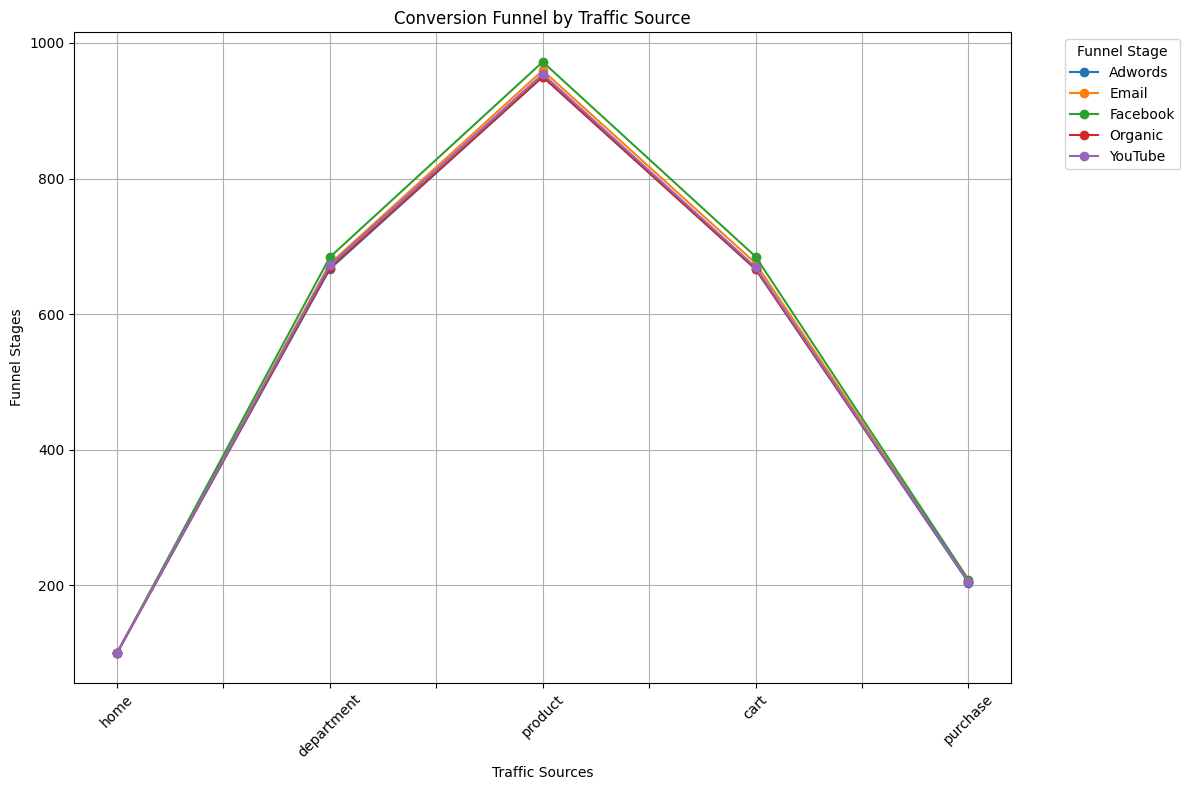

In [43]:
import matplotlib.pyplot as plt

funnel_data_percentage = funnel_data_percentage[funnel_stages]
funnel_data_transposed = funnel_data_percentage.T
funnel_data_transposed.plot(kind='line', marker='o', figsize=(12, 8))

plt.title('Conversion Funnel by Traffic Source')
plt.xlabel('Traffic Sources')
plt.ylabel('Funnel Stages')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend(title='Funnel Stage', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()



# Behavior Analysis by Traffic Source

* This tells us how each traffic source is triggering certain actions on the website. Some traffic sources like email might have more users progressing further into the funnel, while others like organic might drop off early.

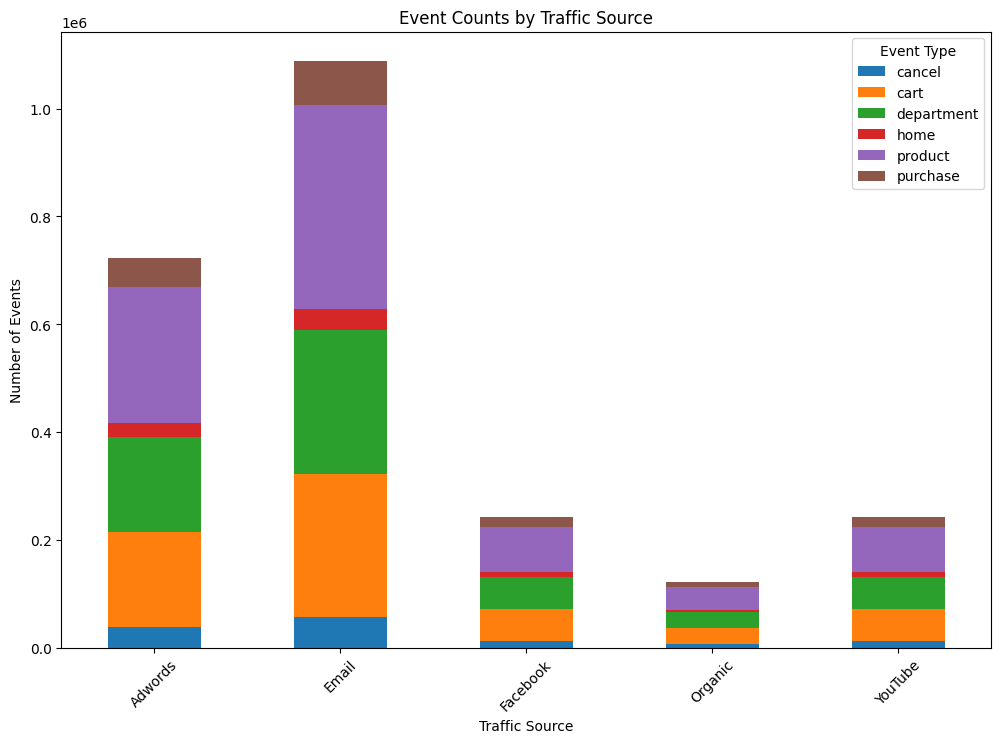

In [26]:
#home: User visits the homepage.
#department: User browses a department or category.
#product: User views a product.
#cart: User adds a product to the cart.
#purchase: User completes a purchase.

event_counts = events_df.groupby(['traffic_source', 'event_type'])['id'].count().unstack(fill_value=0)

event_counts.plot(kind='bar', stacked=True, figsize=(12, 8), title="Event Counts by Traffic Source")
plt.xlabel('Traffic Source')
plt.ylabel('Number of Events')
plt.xticks(rotation=45)
plt.legend(title='Event Type')
plt.show()



# Time-to-Conversion Analysis

*  Shows how long it takes users from each traffic source to move from the first event (home) to the conversion event (purchase). Longer times in the purchase phase could indicate bottlenecks or inefficiencies in that area.



<ipython-input-39-a87fd301216a>:14: FutureWarning: Downcasting behavior in Series and DataFrame methods 'where', 'mask', and 'clip' is deprecated. In a future version this will not infer object dtypes or cast all-round floats to integers. Instead call result.infer_objects(copy=False) for object inference, or cast round floats explicitly. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  time_to_convert.plot(kind='bar', figsize=(12, 8), title="Average Time to Conversion by Traffic Source")


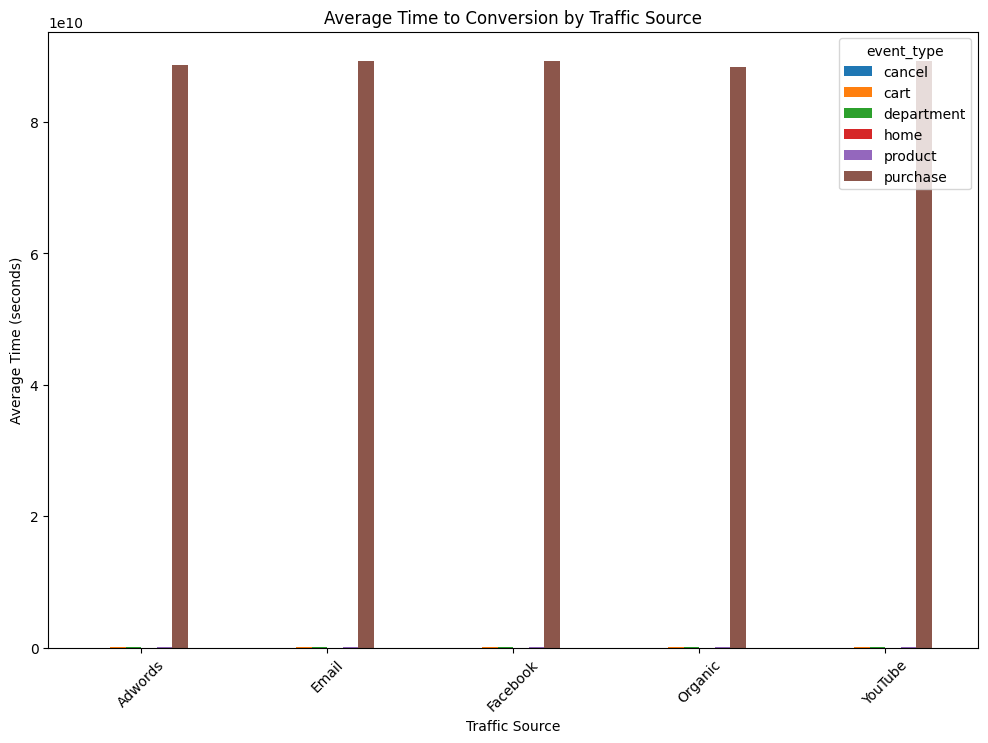

In [39]:

events_df['created_at'] = pd.to_datetime(events_df['created_at'])

events_df.sort_values(['user_id', 'session_id', 'created_at'], inplace=True)

events_df['time_diff'] = events_df.groupby(['user_id', 'session_id'])['created_at'].diff()

time_to_convert = events_df.groupby(['traffic_source', 'event_type'])['time_diff'].mean().unstack()

time_to_convert.plot(kind='bar', figsize=(12, 8), title="Average Time to Conversion by Traffic Source")
plt.xlabel('Traffic Source')
plt.ylabel('Average Time (seconds)')
plt.xticks(rotation=45)
plt.show()


# Recommendations and Insights
* Conversion Bottlenecks: Identify stages with the highest drop-offs and traffic sources that have higher drop-off rates.
* Event Behavior: Explore which traffic sources trigger more important events like 'cart' or 'purchase'.


